# Load Data

In [44]:
# ============================================================
# STEP 0: Imports & Load Data
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats.contingency import association

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import SVC
import xgboost as xgb

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

RANDOM_STATE = 42

DATA_DIR = Path(".\\heart+disease")
FILE_NAMES = [
    "processed.cleveland.data", "processed.hungarian.data",
    "processed.switzerland.data", "processed.va.data",
]
FEATURE_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target",
]

frames = []
for file_name in FILE_NAMES:
    frame = pd.read_csv(DATA_DIR / file_name, header=None, names=FEATURE_NAMES, na_values="?")
    frame["source_file"] = file_name
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
df[FEATURE_NAMES] = df[FEATURE_NAMES].apply(pd.to_numeric, errors="coerce")
df["target_binary"] = (df["target"] > 0).astype(int)
df.drop(columns='target', inplace=True)
df.rename({'target_binary':'target'}, axis=1, inplace=True)

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source_file,target
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,processed.cleveland.data,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.000,0.000,4.000,127.000,333.000,1.000,1.000,154.000,0.000,0.000,NaN,NaN,NaN,processed.va.data,1
916,62.000,1.000,1.000,NaN,139.000,0.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0
917,55.000,1.000,4.000,122.000,223.000,1.000,1.000,100.000,0.000,0.000,NaN,NaN,6.000,processed.va.data,1
918,58.000,1.000,4.000,NaN,385.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0


In [45]:
# change data type for categorical column
columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
for col in columns:
    df[col] = df[col].astype('category')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source_file,target
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,processed.cleveland.data,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.000,0.000,4.000,127.000,333.000,1.000,1.000,154.000,0.000,0.000,NaN,NaN,NaN,processed.va.data,1
916,62.000,1.000,1.000,NaN,139.000,0.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0
917,55.000,1.000,4.000,122.000,223.000,1.000,1.000,100.000,0.000,0.000,NaN,NaN,6.000,processed.va.data,1
918,58.000,1.000,4.000,NaN,385.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0


# EDA

In [47]:
# ============================================================
# STEP 1: EDA Awal (Statistics Descriptive, Cek Missing Value) --> Not related to feature selection, No risk of data leakage
# ============================================================

# 1. Ukuran data
print("1. JUMLAH OBSERVASI DAN FITUR")
print(f"Observasi: {len(df):,}")
print(f"Fitur asli: {len(FEATURE_NAMES) - 1:,} | Target: 1 | Kolom metadata: source_file, target")

1. JUMLAH OBSERVASI DAN FITUR
Observasi: 920
Fitur asli: 13 | Target: 1 | Kolom metadata: source_file, target


In [48]:
# 2. Data Type tiap Fitur
print("\n2. TIPE SETIAP FITUR")
type_table = pd.DataFrame({
    "feature": df[FEATURE_NAMES].columns,
    "dtype": df[FEATURE_NAMES].dtypes.astype(str).values,
    "n_unique": df[FEATURE_NAMES].nunique(dropna=True).values,
})
display(type_table)


2. TIPE SETIAP FITUR


,feature,dtype,n_unique
0,age,float64,50
1,sex,category,2
2,cp,category,4
3,trestbps,float64,61
4,chol,float64,217
5,fbs,category,2
6,restecg,category,3
7,thalach,float64,119
8,exang,category,2
9,oldpeak,float64,53


3. DISTRIBUSI TARGET


,count,percentage
target,,
0,411,44.674
1,509,55.326


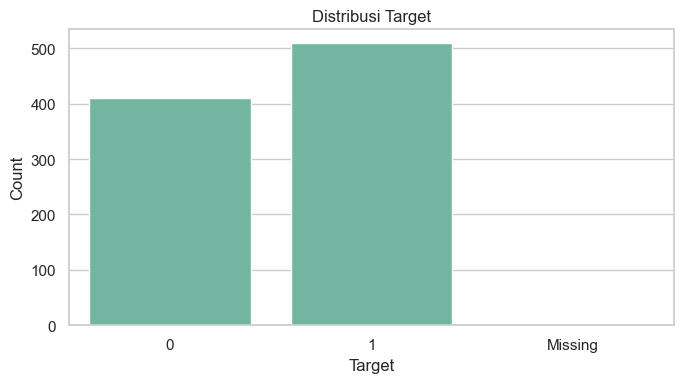

In [49]:
# 2. Distribusi Target
print("3. DISTRIBUSI TARGET")
target_distribution = pd.DataFrame({
    "count": df["target"].value_counts(dropna=False).sort_index(),
    "percentage": df["target"].value_counts(normalize=True, dropna=False).sort_index().mul(100),
})
display(target_distribution)

# tambahkan kategori "Missing" dulu sebelum fillna, karena dtype-nya category
target_plot = df["target"].cat.add_categories(["Missing"]).fillna("Missing")

plt.figure(figsize=(7, 4))
sns.countplot(
    x=target_plot,
    order=target_plot.value_counts().sort_index().index
)
plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [50]:
# 4. Cek Missing Value
print("4. MISSING VALUES")
missing_table = pd.DataFrame({
    "missing_count": df[FEATURE_NAMES].isna().sum(),
    "missing_percentage": df[FEATURE_NAMES].isna().mean().mul(100),
}).sort_values("missing_count", ascending=False)
display(missing_table)

4. MISSING VALUES


,missing_count,missing_percentage
ca,611,66.413
thal,486,52.826
slope,309,33.587
fbs,90,9.783
oldpeak,62,6.739
trestbps,59,6.413
thalach,55,5.978
exang,55,5.978
chol,30,3.261
restecg,2,0.217


In [52]:
# 5. Cek Duplikat
print("5. DUPLICATE RECORDS")
print(f"Duplikat penuh (tanpa source_file): {df[FEATURE_NAMES].duplicated().sum():,}")
print(f"Duplikat identik antar semua kolom: {df.duplicated().sum():,}")

5. DUPLICATE RECORDS
Duplikat penuh (tanpa source_file): 2
Duplikat identik antar semua kolom: 2


6. DISTRIBUSI NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
age,920.000,53.511,9.425,28.000,47.000,54.000,60.000,77.000
trestbps,861.000,132.132,19.066,0.000,120.000,130.000,140.000,200.000
chol,890.000,199.130,110.781,0.000,175.000,223.000,268.000,603.000
thalach,865.000,137.546,25.926,60.000,120.000,140.000,157.000,202.000
oldpeak,858.000,0.879,1.091,-2.600,0.000,0.500,1.500,6.200


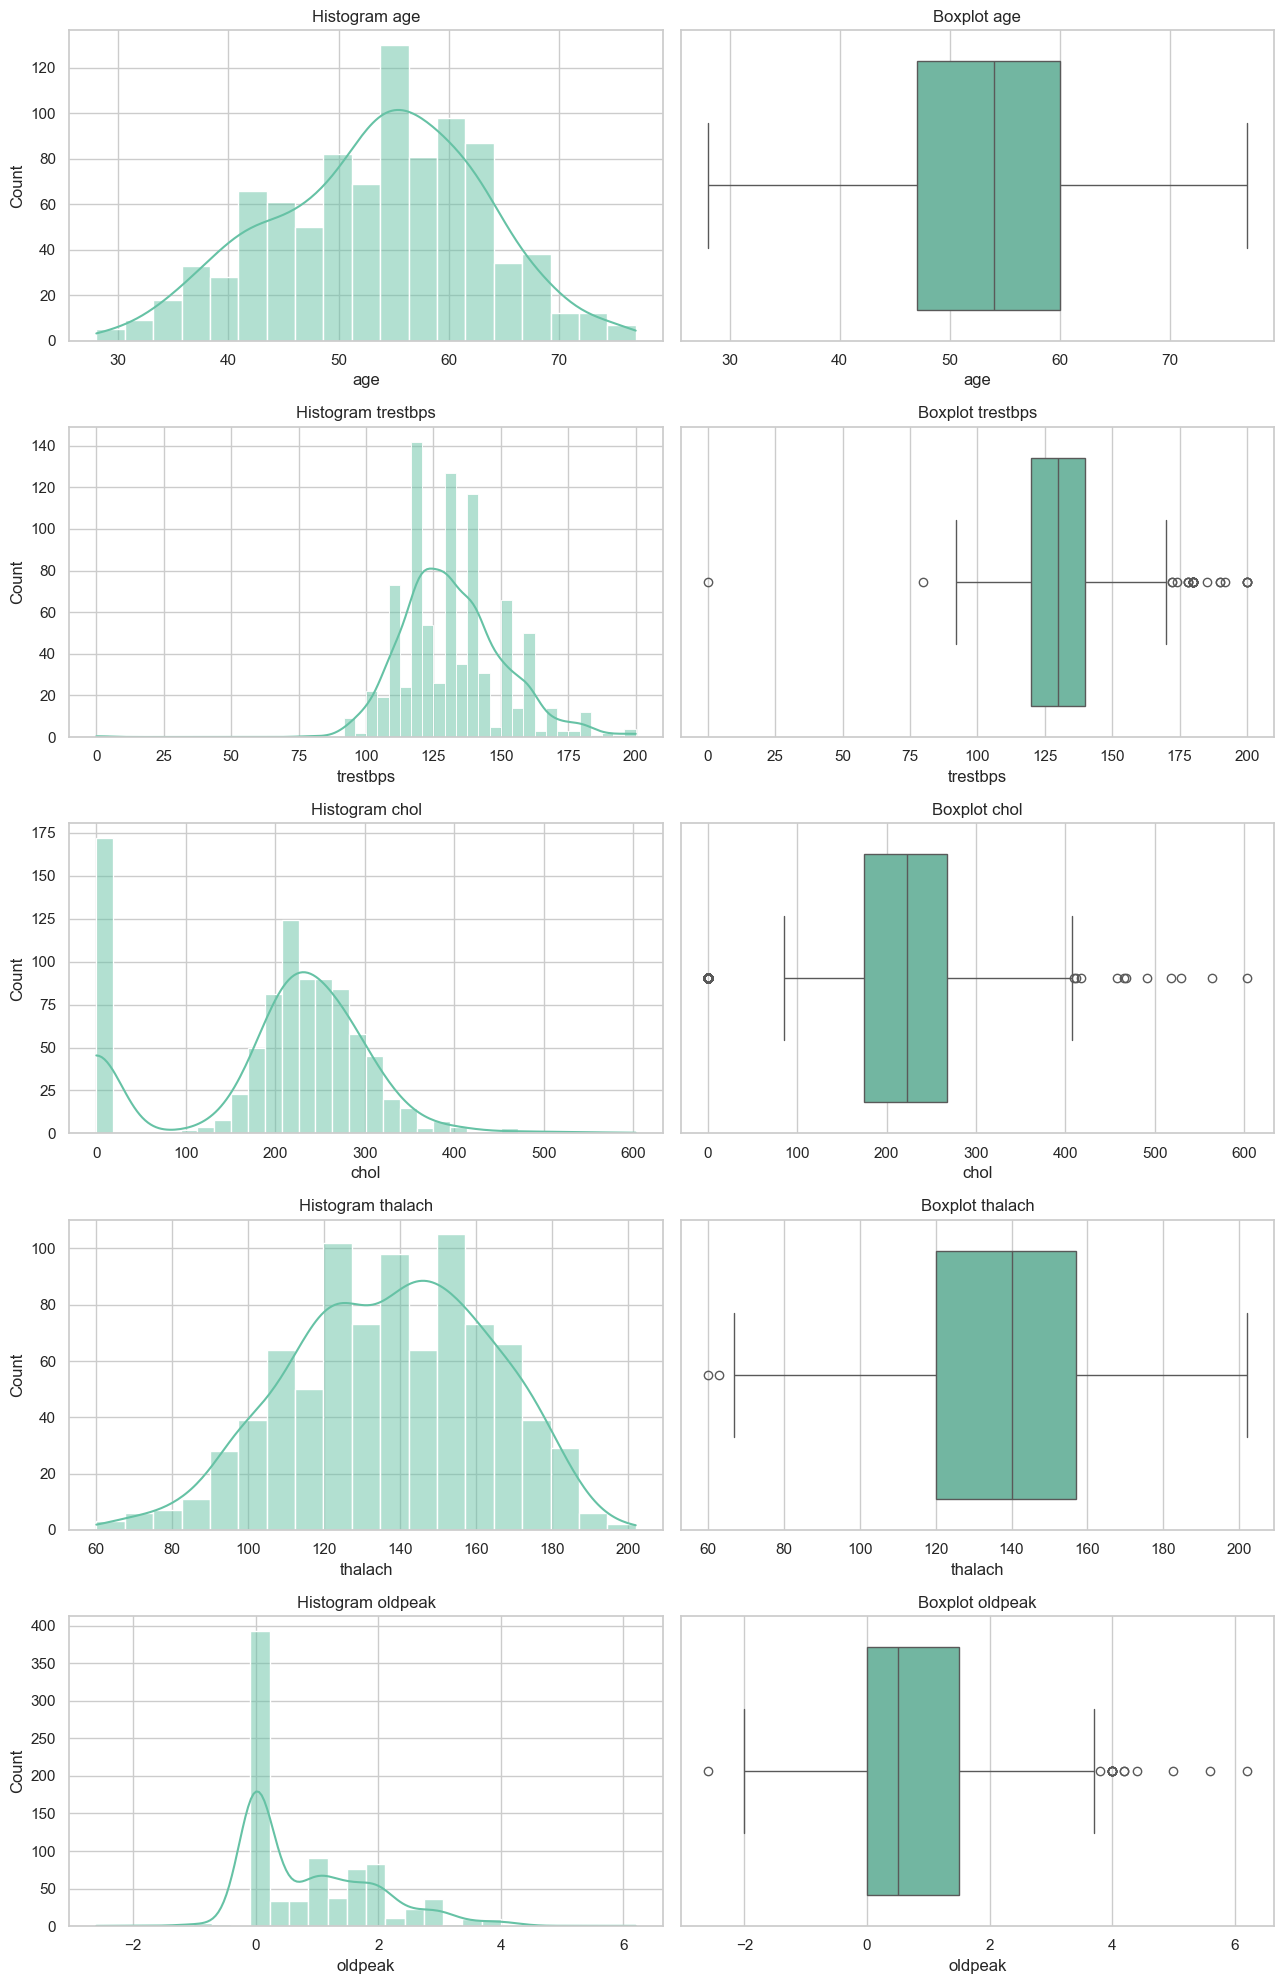

In [53]:
# 6. Distribusi fitur numerik
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("6. DISTRIBUSI NUMERICAL FEATURES")
display(df[numeric_features].describe().T)
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(13, 4 * len(numeric_features)))
for row, feature in enumerate(numeric_features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[row, 0])
    axes[row, 0].set_title(f"Histogram {feature}")
    sns.boxplot(data=df, x=feature, ax=axes[row, 1])
    axes[row, 1].set_title(f"Boxplot {feature}")
plt.tight_layout()
plt.show()

7. DISTRIBUSI CATEGORICAL FEATURES

sex


,count,percentage
sex,,
1.000,726,78.913
0.000,194,21.087
Missing,0,0.000


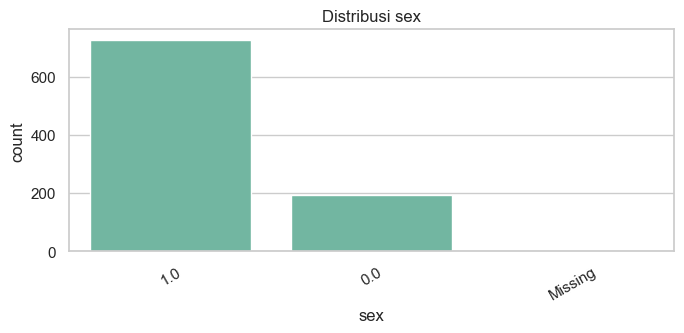


cp


,count,percentage
cp,,
4.000,496,53.913
3.000,204,22.174
2.000,174,18.913
1.000,46,5.000
Missing,0,0.000


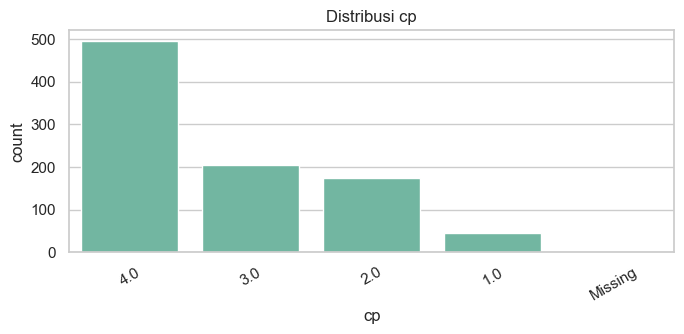


fbs


,count,percentage
fbs,,
0.000,692,75.217
1.000,138,15.000
Missing,90,9.783


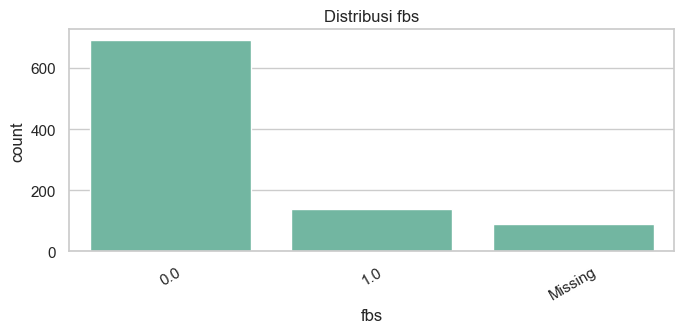


restecg


,count,percentage
restecg,,
0.000,551,59.891
2.000,188,20.435
1.000,179,19.457
Missing,2,0.217


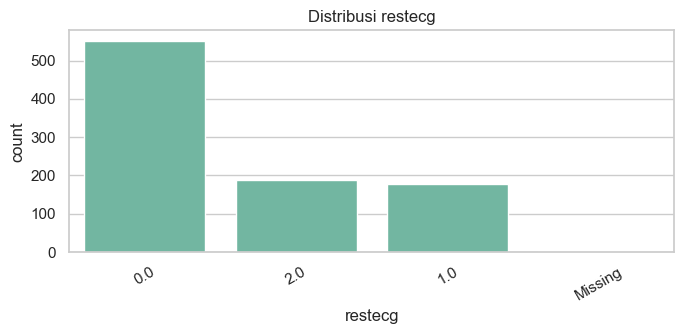


exang


,count,percentage
exang,,
0.000,528,57.391
1.000,337,36.630
Missing,55,5.978


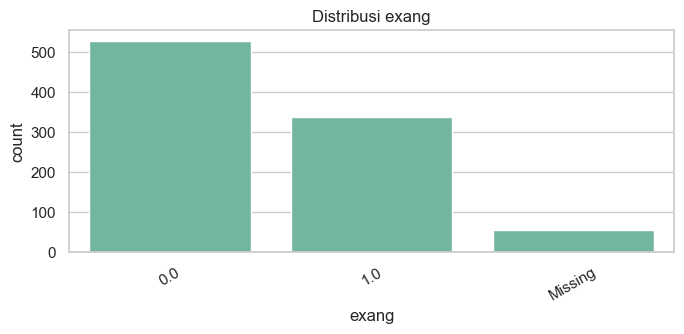


slope


,count,percentage
slope,,
2.000,345,37.500
Missing,309,33.587
1.000,203,22.065
3.000,63,6.848


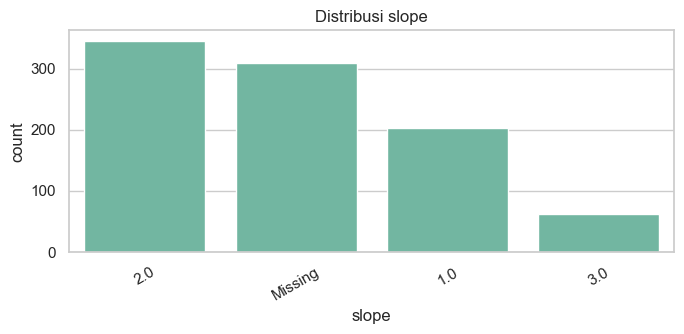


ca


,count,percentage
ca,,
Missing,611,66.413
0.000,181,19.674
1.000,67,7.283
2.000,41,4.457
3.000,20,2.174


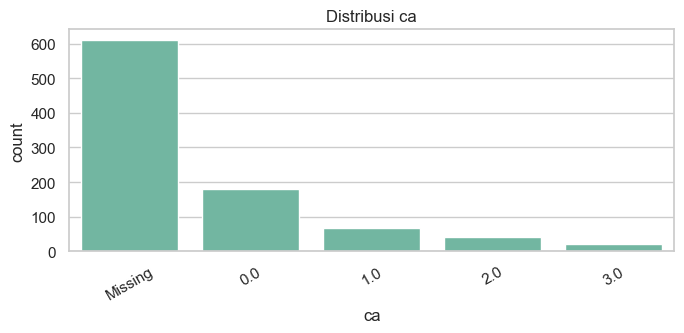


thal


,count,percentage
thal,,
Missing,486,52.826
3.000,196,21.304
7.000,192,20.870
6.000,46,5.000


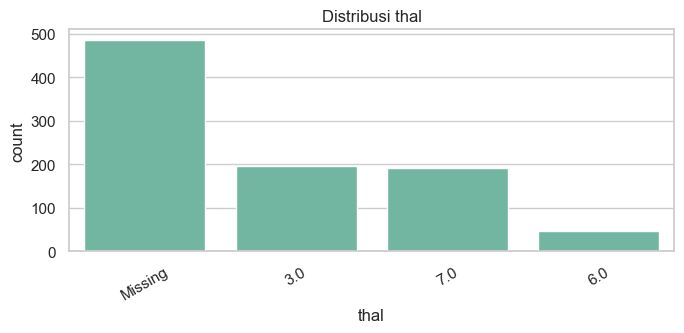

In [54]:
# 6. Distribusi fitur kategorik
print("7. DISTRIBUSI CATEGORICAL FEATURES")
for feature in categorical_features:
    series = df[feature]

    # tangani category dtype dan non-category dtype secara berbeda
    if isinstance(series.dtype, pd.CategoricalDtype):
        if "Missing" not in series.cat.categories:
            series = series.cat.add_categories(["Missing"])
        plot_series = series.fillna("Missing")
    else:
        plot_series = series.astype(str).fillna("Missing")

    distribution = plot_series.value_counts(dropna=False).rename_axis(feature).to_frame("count")
    distribution["percentage"] = distribution["count"].div(len(df)).mul(100)
    print(f"\n{feature}")
    display(distribution)

    plt.figure(figsize=(7, 3.5))
    sns.countplot(x=plot_series, order=plot_series.value_counts(dropna=False).index)
    plt.title(f"Distribusi {feature}")
    plt.xlabel(feature)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [55]:
# 8. Cek Anomali
print("8. ANOMALOUS VALUES (ATURAN DOMAIN)")
domain_rules = {
    "age": (0, 120),
    "sex": (0, 1),
    "cp": (1, 4),
    "trestbps": (50, 250),
    "chol": (50, 700),
    "fbs": (0, 1),
    "restecg": (0, 2),
    "thalach": (50, 250),
    "exang": (0, 1),
    "oldpeak": (-5, 10),
    "slope": (1, 3),
    "ca": (0, 3),
    "thal": (3, 7),
    "target": (0, 1),
}
anomaly_rows = []
for feature, (lower, upper) in domain_rules.items():
    # cast ke numerik untuk perbandingan, aman untuk category dtype maupun dtype lain
    values = pd.to_numeric(df[feature], errors="coerce")
    mask = values.notna() & ~values.between(lower, upper)
    anomaly_rows.append({
        "feature": feature,
        "allowed_range": f"[{lower}, {upper}]",
        "anomaly_count": int(mask.sum()),
        "anomaly_percentage": mask.mean() * 100,
    })
anomaly_table = pd.DataFrame(anomaly_rows).sort_values("anomaly_count", ascending=False)
display(anomaly_table)
print("Catatan: batas domain adalah screening awal; nilai yang lolos tetap perlu ditinjau secara klinis.")

8. ANOMALOUS VALUES (ATURAN DOMAIN)


,feature,allowed_range,anomaly_count,anomaly_percentage
4,chol,"[50, 700]",172,18.696
3,trestbps,"[50, 250]",1,0.109
1,sex,"[0, 1]",0,0.000
0,age,"[0, 120]",0,0.000
2,cp,"[1, 4]",0,0.000
5,fbs,"[0, 1]",0,0.000
6,restecg,"[0, 2]",0,0.000
7,thalach,"[50, 250]",0,0.000
8,exang,"[0, 1]",0,0.000
9,oldpeak,"[-5, 10]",0,0.000


Catatan: batas domain adalah screening awal; nilai yang lolos tetap perlu ditinjau secara klinis.


9. OUTLIER ANALYSIS (IQR)


,feature,q1,q3,lower_bound,upper_bound,outlier_count,outlier_percentage
2,chol,175.000,268.000,35.500,407.500,183,19.891
1,trestbps,120.000,140.000,90.000,170.000,28,3.043
4,oldpeak,0.000,1.500,-2.250,3.750,16,1.739
3,thalach,120.000,157.000,64.500,212.500,2,0.217
0,age,47.000,60.000,27.500,79.500,0,0.000


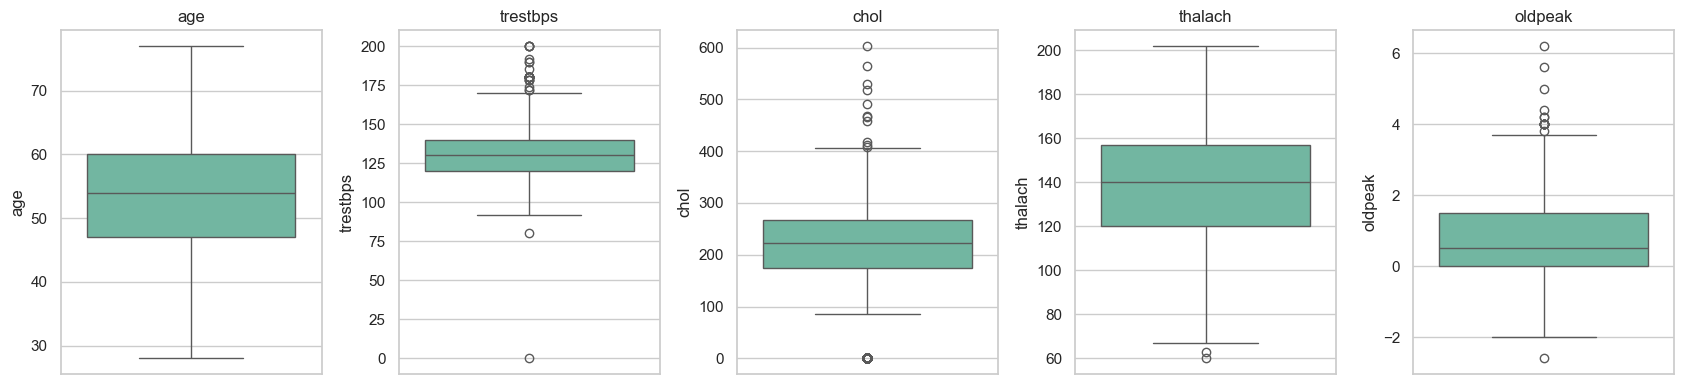

In [56]:
# 9. Cek Outlier
print("9. OUTLIER ANALYSIS (IQR)")
outlier_rows = []
for feature in numeric_features:
    values = df[feature].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = df[feature].notna() & ~df[feature].between(lower, upper)
    outlier_rows.append({
        "feature": feature,
        "q1": q1,
        "q3": q3,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_percentage": mask.mean() * 100,
    })
outlier_table = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_table)

fig, axes = plt.subplots(1, len(numeric_features), figsize=(17, 4))
for axis, feature in zip(axes, numeric_features):
    sns.boxplot(data=df, y=feature, ax=axis)
    axis.set_title(feature)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 2: Tipe Fitur (cp direklasifikasi menjadi nominal;
# slope, ca, thal akan di-drop di awal karena missing rate ekstrem)
# ============================================================
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
binary_features = ["sex", "fbs", "exang"]
nominal_features = ["cp", "restecg"]
dropped_features = ["slope", "ca", "thal"]  # missing rate 33.6% / 66.4% / 52.8%

all_used_features = numeric_features + binary_features + nominal_features
all_used_features

['age',
 'trestbps',
 'chol',
 'thalach',
 'oldpeak',
 'sex',
 'fbs',
 'exang',
 'cp',
 'restecg']

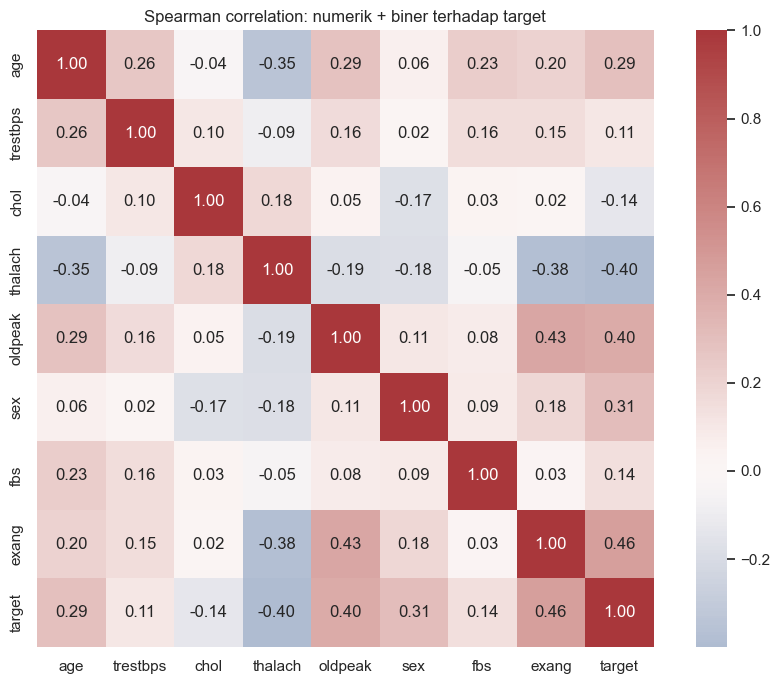


Cramér's V (fitur nominal vs target):


,feature,cramers_v
0,cp,0.540
1,restecg,0.113


In [61]:
# ============================================================
# STEP 3: Correlation Analysis
# (Spearman untuk numerik+biner; Cramér's V untuk nominal,
#  dihitung dari SELURUH df hanya untuk keperluan eksplorasi awal;
#  keputusan fitur final tetap berdasarkan domain knowledge di Step Selanjutnya)
# ============================================================
spearman_features = numeric_features + binary_features
spearman_corr = df[spearman_features + ["target"]].corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Spearman correlation: numerik + biner terhadap target")
plt.tight_layout()
plt.show()

print("\nCramér's V (fitur nominal vs target):")
cramers_rows = []
for feature in nominal_features:
    table = pd.crosstab(df[feature], df["target"])
    cramers_rows.append({"feature": feature, "cramers_v": association(table, method="cramer")})
display(pd.DataFrame(cramers_rows).sort_values("cramers_v", ascending=False))

# Drop Columns with Missing Rate Extreme

In [ ]:
# ============================================================
# STEP 4: Recode Structural Zero & Drop Fitur Missing Ekstrem
# ============================================================
df["chol"] = df["chol"].replace(0, np.nan)
df["trestbps"] = df["trestbps"].replace(0, np.nan)
# oldpeak=0 TIDAK di-recode — nilai 0 valid secara klinis (no ST depression)

print(f"\nFitur dikecualikan (missing rate ekstrem): {dropped_features}")
print(f"Fitur ({len(all_used_features)}): {all_used_features}")


Fitur dikecualikan (missing rate ekstrem): ['slope', 'ca', 'thal']
Fitur (10): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'fbs', 'exang', 'cp', 'restecg']


# Split Data

In [ ]:
# ============================================================
# STEP 5: Outer Train/Test Split (70%, 30%)
# ============================================================
X = df[all_used_features].copy()
y = df["target"].copy()

X_train_pool, X_test, y_train_pool, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
print(f"\nTraining pool: {X_train_pool.shape}, Test set: {X_test.shape}")


Training pool: (644, 10), Test set: (276, 10)


## K-Fold Cross Validation

In [ ]:
# ============================================================
# STEP 6: Stratified K-Fold (K=5) — inner CV untuk tuning
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## Preprocessing

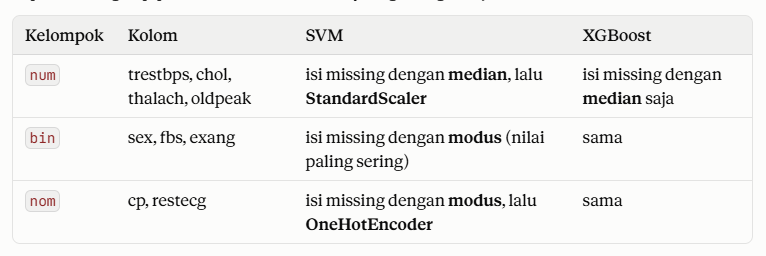 

**SVM** : Menggunakan kernel RBF bekerja dengan jarak antar titik, jadi fitur berskala besar (misalnya chol sekitar 200) <br> akan mendominasi fitur berskala kecil (oldpeak sekitar 0-6), sehingga perlu standarisasi skalanya. <br>
**XGBoost** : Model berbasis pohon yang hanya melihat urutan nilai, sehingga scaling tidak memengaruhi hasil.<br>

**Other Preprocessing** <br>
*One-hot*: cp dan restecg diubah jadi kolom 0/1 per kategori karena angkanya hanya label, bukan urutan. <br> handle_unknown="ignore" mencegah error kalau ada kategori yang muncul di data test tapi tidak ada di train.<br>
*Output*: kira-kira 14 kolom, dengan nama seperti num__chol, bin__sex, nom__cp_3.0. Kolom ini yang kemudian disaring SelectFromModel.<br>
Tidak ada kebocoran data: karena preprocessor ada di dalam Pipeline, median, modus, dan mean/std dihitung ulang dari data training tiap fold, <br>lalu diterapkan ke data validasi atau test.<br>
Kolom yang tidak terdaftar dibuang (remainder="drop" adalah default).

In [ ]:
# ============================================================
# STEP 7: Preprocessing Pipelines
# (SVM butuh scaling; XGBoost tidak)
# ============================================================
numeric_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
numeric_pipeline_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor_svm = ColumnTransformer([
    ("num", numeric_pipeline_scaled, numeric_features),
    ("bin", binary_pipeline, binary_features),
    ("nom", nominal_pipeline, nominal_features),
])
preprocessor_xgb = ColumnTransformer([
    ("num", numeric_pipeline_unscaled, numeric_features),
    ("bin", binary_pipeline, binary_features),
    ("nom", nominal_pipeline, nominal_features),
])

## GridSearch Cross Validation

In [ ]:
# ============================================================
# STEP 8: Pipeline + GridSearchCV — XGBoost (feature selection via SelectFromModel)
# ============================================================
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor_xgb),
    ("feature_selection", SelectFromModel(
        xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
        threshold="median"
    )),
    ("model", xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="logloss", random_state=RANDOM_STATE
    )),
])

xgb_param_grid = {
    "feature_selection__threshold": ["median", "mean"],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
}

xgb_search = GridSearchCV(
    xgb_pipe, xgb_param_grid, cv=cv, scoring="accuracy", n_jobs=-1, refit=True
)
xgb_search.fit(X_train_pool, y_train_pool)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'feature_selection__threshold': ['median', 'mean'], 'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-va

In [68]:
# ============================================================
# STEP 9: Pipeline + GridSearchCV — SVM
# (feature selection via linear SVM, model final tetap RBF kernel)
# ============================================================
svm_pipe = Pipeline([
    ("preprocessor", preprocessor_svm),
    ("feature_selection", SelectFromModel(
        SVC(kernel="linear", random_state=RANDOM_STATE),
        threshold="median"
    )),
    ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
])

svm_param_grid = {
    "feature_selection__threshold": ["median", "mean"],
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1],
}

svm_search = GridSearchCV(
    svm_pipe, svm_param_grid, cv=cv, scoring="accuracy", n_jobs=-1, refit=True
)
svm_search.fit(X_train_pool, y_train_pool)

c:\Users\Rizka Akmalia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'feature_selection__threshold': ['median', 'mean'], 'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for c

In [69]:
# ============================================================
# STEP 10: Hasil Akhir — CV Score, Test Score, Fitur Terpilih
# ============================================================
for name, search, preproc in [("XGBoost", xgb_search, preprocessor_xgb),
                                ("SVM", svm_search, preprocessor_svm)]:
    print(f"\n=== {name} ===")
    print(f"Best params: {search.best_params_}")
    print(f"Best CV accuracy: {search.best_score_:.4f}")
    print(f"Test accuracy: {search.score(X_test, y_test):.4f}")

    feature_names_out = preproc.fit(X_train_pool).get_feature_names_out()
    selected_mask = search.best_estimator_.named_steps["feature_selection"].get_support()
    selected_features = feature_names_out[selected_mask]
    print(f"Fitur terpilih ({selected_mask.sum()}/{len(selected_mask)}): {list(selected_features)}")


=== XGBoost ===
Best params: {'feature_selection__threshold': 'median', 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 200}
Best CV accuracy: 0.7718
Test accuracy: 0.7899
Fitur terpilih (8/15): ['num__age', 'num__oldpeak', 'bin__sex', 'bin__exang', 'nom__cp_1.0', 'nom__cp_2.0', 'nom__cp_4.0', 'nom__restecg_1.0']

=== SVM ===
Best params: {'feature_selection__threshold': 'median', 'model__C': 10, 'model__gamma': 0.01}
Best CV accuracy: 0.7857
Test accuracy: 0.7826
Fitur terpilih (8/15): ['num__age', 'num__thalach', 'num__oldpeak', 'bin__sex', 'bin__exang', 'nom__cp_1.0', 'nom__cp_2.0', 'nom__cp_4.0']


In [70]:
# ============================================================
# STEP 11: Model final (hasil refit GridSearchCV di train pool)
# ============================================================
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_validate, LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay,
)

final_models = {
    "SVM (tuned)": svm_search.best_estimator_,
    "XGBoost (tuned)": xgb_search.best_estimator_,
}


=== HASIL TEST SET ===


,accuracy,balanced_acc,precision,recall (sensitivity),specificity,f1,roc_auc,cv_accuracy
SVM (tuned),0.783,0.778,0.792,0.824,0.732,0.808,0.889,0.786
XGBoost (tuned),0.790,0.782,0.784,0.856,0.707,0.819,0.882,0.772


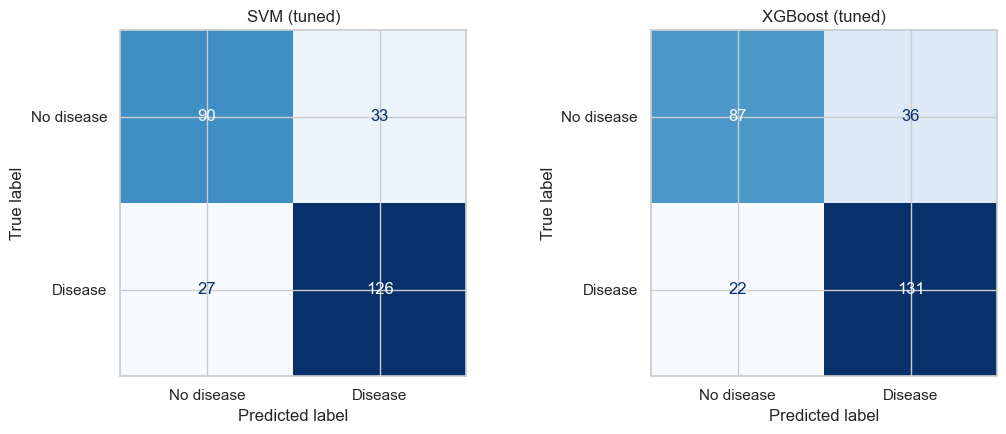

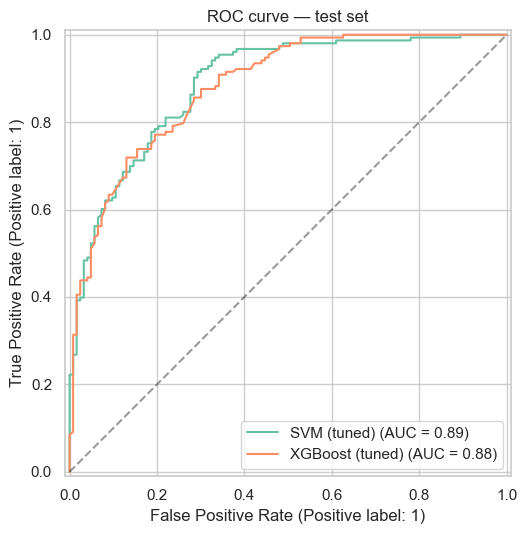

In [71]:
# ============================================================
# STEP 12: Evaluasi lengkap di test set (dilakukan SEKALI)
# ============================================================
def evaluate(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    proba = model.predict_proba(X_eval)[:, 1]
    return {
        "accuracy": accuracy_score(y_eval, pred),
        "balanced_acc": balanced_accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall (sensitivity)": recall_score(y_eval, pred),
        "specificity": recall_score(y_eval, pred, pos_label=0),
        "f1": f1_score(y_eval, pred),
        "roc_auc": roc_auc_score(y_eval, proba),
    }

results = pd.DataFrame(
    {name: evaluate(model, X_test, y_test) for name, model in final_models.items()}
).T

# skor CV di train pool sebagai pembanding terhadap skor test
results["cv_accuracy"] = pd.Series({
    "SVM (tuned)": svm_search.best_score_,
    "XGBoost (tuned)": xgb_search.best_score_,
})
print("\n=== HASIL TEST SET ===")
display(results.sort_values("roc_auc", ascending=False))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, ["SVM (tuned)", "XGBoost (tuned)"]):
    ConfusionMatrixDisplay.from_estimator(
        final_models[name], X_test, y_test,
        display_labels=["No disease", "Disease"], cmap="Blues", ax=ax, colorbar=False,
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

# ROC curve
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, model in final_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("ROC curve — test set")
plt.tight_layout()
plt.show()

# Optional Checking

In [72]:
# ============================================================
# STEP 14: Optional Bootstrap CI (test set kecil -> estimasi punya ketidakpastian)
# + paired bootstrap untuk selisih SVM vs XGBoost
# ============================================================
def bootstrap_ci(y_true, y_hat, metric, n_boot=1000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric(y_true[idx], y_hat[idx]))
    return np.percentile(scores, [2.5, 97.5])

preds = {n: final_models[n].predict(X_test) for n in ["SVM (tuned)", "XGBoost (tuned)"]}
probas = {n: final_models[n].predict_proba(X_test)[:, 1] for n in preds}

ci_rows = []
for name in preds:
    acc_lo, acc_hi = bootstrap_ci(y_test, preds[name], accuracy_score)
    auc_lo, auc_hi = bootstrap_ci(y_test, probas[name], roc_auc_score)
    ci_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds[name]),
        "acc_95CI": f"[{acc_lo:.3f}, {acc_hi:.3f}]",
        "roc_auc": roc_auc_score(y_test, probas[name]),
        "auc_95CI": f"[{auc_lo:.3f}, {auc_hi:.3f}]",
    })
print("\n=== BOOTSTRAP 95% CI (test set) ===")
display(pd.DataFrame(ci_rows))

# paired bootstrap: selisih akurasi XGBoost - SVM pada sampel bootstrap yang sama
rng = np.random.default_rng(RANDOM_STATE)
y_arr = y_test.to_numpy()
correct_xgb = (preds["XGBoost (tuned)"] == y_arr).astype(float)
correct_svm = (preds["SVM (tuned)"] == y_arr).astype(float)
diffs = []
for _ in range(2000):
    idx = rng.integers(0, len(y_arr), len(y_arr))
    diffs.append(correct_xgb[idx].mean() - correct_svm[idx].mean())
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"\nSelisih akurasi (XGBoost - SVM): {correct_xgb.mean() - correct_svm.mean():+.3f}, 95% CI [{lo:+.3f}, {hi:+.3f}]")
print("Kalau CI mencakup 0, perbedaan kedua model tidak bisa dibedakan dari noise.")


=== BOOTSTRAP 95% CI (test set) ===


,model,accuracy,acc_95CI,roc_auc,auc_95CI
0,SVM (tuned),0.783,"[0.732, 0.833]",0.889,"[0.847, 0.929]"
1,XGBoost (tuned),0.790,"[0.743, 0.841]",0.882,"[0.842, 0.922]"



Selisih akurasi (XGBoost - SVM): +0.007, 95% CI [-0.029, +0.043]
Kalau CI mencakup 0, perbedaan kedua model tidak bisa dibedakan dari noise.


In [73]:
# ============================================================
# STEP 16: Robustness antar sumber data (Cleveland/Hungarian/Switzerland/VA)
# Empat dataset digabung; distribusi tiap RS berbeda, jadi cek konsistensinya.
# ============================================================
# (a) Akurasi test set per sumber
source_test = df.loc[X_test.index, "source_file"].to_numpy()
y_test_arr = y_test.to_numpy()
rows = []
for name in preds:
    for src in sorted(np.unique(source_test)):
        m = source_test == src
        rows.append({
            "model": name, "source": src, "n_test": int(m.sum()),
            "positive_rate": y_test_arr[m].mean(),
            "accuracy": accuracy_score(y_test_arr[m], preds[name][m]),
        })
print("\n=== AKURASI TEST SET PER SUMBER ===")
display(pd.DataFrame(rows))

# (b) Leave-one-source-out di train pool (hyperparameter tetap = hasil GridSearch).
# Menjawab: "kalau dilatih di 3 sumber, apakah bisa generalisasi ke sumber ke-4?"
groups_pool = df.loc[X_train_pool.index, "source_file"]
group_order = sorted(groups_pool.unique())
loso_rows = []
for name, search in [("SVM (tuned)", svm_search), ("XGBoost (tuned)", xgb_search)]:
    res = cross_validate(
        clone(search.best_estimator_), X_train_pool, y_train_pool,
        groups=groups_pool, cv=LeaveOneGroupOut(),
        scoring=["accuracy", "roc_auc"], error_score=np.nan, n_jobs=1,
    )
    for grp, acc, auc in zip(group_order, res["test_accuracy"], res["test_roc_auc"]):
        loso_rows.append({"model": name, "held_out_source": grp, "accuracy": acc, "roc_auc": auc})
print("\n=== LEAVE-ONE-SOURCE-OUT (train pool) ===")
display(pd.DataFrame(loso_rows))


=== AKURASI TEST SET PER SUMBER ===


,model,source,n_test,positive_rate,accuracy
0,SVM (tuned),processed.cleveland.data,90,0.489,0.789
1,SVM (tuned),processed.hungarian.data,96,0.365,0.802
2,SVM (tuned),processed.switzerland.data,39,0.949,0.821
3,SVM (tuned),processed.va.data,51,0.725,0.706
4,XGBoost (tuned),processed.cleveland.data,90,0.489,0.811
5,XGBoost (tuned),processed.hungarian.data,96,0.365,0.760
6,XGBoost (tuned),processed.switzerland.data,39,0.949,0.846
7,XGBoost (tuned),processed.va.data,51,0.725,0.765


c:\Users\Rizka Akmalia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Rizka Akmalia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Rizka Akmalia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Rizka Akmalia\AppData\Local\Programs\Python\Python31


=== LEAVE-ONE-SOURCE-OUT (train pool) ===


,model,held_out_source,accuracy,roc_auc
0,SVM (tuned),processed.cleveland.data,0.704,0.851
1,SVM (tuned),processed.hungarian.data,0.747,0.870
2,SVM (tuned),processed.switzerland.data,0.702,0.735
3,SVM (tuned),processed.va.data,0.765,0.718
4,XGBoost (tuned),processed.cleveland.data,0.695,0.823
5,XGBoost (tuned),processed.hungarian.data,0.727,0.819
6,XGBoost (tuned),processed.switzerland.data,0.667,0.684
7,XGBoost (tuned),processed.va.data,0.738,0.706
